# Motivation for a new loss

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
from PIL import Image, ImageFilter
import numpy as np
img = Image.open("/content/drive/MyDrive/hanyang/eachneuron.jpg")
blurred = img.filter(ImageFilter.GaussianBlur(radius=10))
blurred.save("/content/drive/MyDrive/hanyang/blurredneuron.jpg")
mse = ((np.array(img)/255.0 - np.array(blurred)/255.0) ** 2).mean()
print(mse)

0.03165352937514876


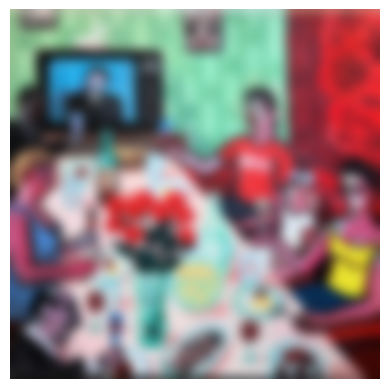

In [6]:
import matplotlib.pyplot as plt

plt.imshow(blurred)
plt.axis("off")
plt.show()


You can see that the loss is pretty small although from a human point of view, the blurred photo is far away from the original.

### Example of code to get a perceptual loss

In [ ]:
import torchvision
import torch.nn.functional as F

vgg = torchvision.models.vgg16(weights="DEFAULT").features.eval()
for p in vgg.parameters():
    p.requires_grad_(False) 

def extract(x, layers={3, 8, 15, 22}):
    feats = []
    for i, layer in enumerate(vgg):
        x = layer(x)
        if i in layers:
            feats.append(x)
    return feats

def perceptual_loss(y_hat, y):
    fx, fy = extract(y_hat), extract(y)
    return sum(F.mse_loss(a, b) for a, b in zip(fx, fy))

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:07<00:00, 78.9MB/s]


It's interesting to see that we choose layers from the beginning, middle, and end as we know that the end will be focused on details features and the beginning on bigger features (semantic), shapes, ... 

In [ ]:
import torch
from torchvision import transforms

# FOLLOWING the vgg16 constraints
preprocess = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

img_tensor     = preprocess(img).unsqueeze(0)
blurred_tensor = preprocess(blurred).unsqueeze(0)

loss = perceptual_loss(blurred_tensor, img_tensor)
print(f"Perceptual loss : {loss.item():.4f}")
print(f"MSE pixel       : {((torch.tensor(np.array(img))/255.0 - torch.tensor(np.array(blurred))/255.0)**2).mean().item():.4f}")

Perceptual loss : 32.0381
MSE pixel       : 0.0317


You can see that from the perceptual loss point of view, the 2 images are considered a lot different. 